# Project Two: Logistic Regression and Random Forests

For Project Two, you have been asked to create different models analyzing a Heart Disease data set. Before beginning work on the project, be sure to read through the Project Two Guidelines and Rubric to understand what you need to do and how you will be graded on this assignment. Be sure to carefully review the Project Two Summary Report template, which contains all of the questions that you will need to answer about the regression analyses you are performing.

For this project, you will be writing all the scripts yourself. You may reference the textbook and your previous work on the problem sets to help you write the scripts.


### Scenario

You are a data analyst researching risk factors for heart disease at a university hospital. You have access to a large set of historical data that you can use to analyze patterns between different health indicators (e.g. fasting blood sugar, maximum heart rate, etc.) and the presence of heart disease. You have been asked to create different logistic regression models that predict whether or not a person is at risk for heart disease. A model like this could eventually be used to evaluate medical records and look for risks that might not be obvious to human doctors. You have also been asked to create a classification random forest model to predict the risk of heart disease and a regression random forest model to predict the maximum heart rate achieved.

There are several variables in this data set, but you will be working with the following important variables: 

| <div style="text-align: left"> Variable </div>  |   <div style="text-align: left"> What does it represent? </div> |
| -- | --  |
| <div style="text-align: left"> age </div> | <div style="text-align: left"> The person's age in years </div> |
| <div style="text-align: left"> sex </div> | <div style="text-align: left"> The person's sex (1 = male, 0 = female) </div> |
| <div style="text-align: left"> cp </div> | <div style="text-align: left"> The type of chest pain experienced (0=no pain, 1=typical angina, 2=atypical angina, 3=non-anginal pain) </div> |
| <div style="text-align: left"> trestbps </div> | <div style="text-align: left"> The person's resting blood pressure </div> |
| <div style="text-align: left"> chol </div> | <div style="text-align: left"> The person's cholesterol measurement in mg/dl </div> |
| <div style="text-align: left"> fbs </div> | <div style="text-align: left"> The person's fasting blood sugar is greater than 120 mg/dl (1 = true, 0 = false) </div> |
| <div style="text-align: left"> restecg </div> | <div style="text-align: left"> Resting electrocardiographic measurement (0=normal, 1=having ST-T wave abnormality, 2=showing probable or definite left ventricular hypertrophy by Estes' criteria) </div> |
| <div style="text-align: left"> thalach </div> | <div style="text-align: left"> The person's maximum heart rate achieved </div> |
| <div style="text-align: left"> exang </div> | <div style="text-align: left"> Exercise-induced angina (1=yes, 0=no) </div> |
| <div style="text-align: left"> oldpeak </div> | <div style="text-align: left"> ST depression induced by exercise relative to rest ('ST' relates to positions on the ECG plot) </div> |
| <div style="text-align: left"> slope </div> | <div style="text-align: left"> The slope of the peak exercise ST segment (1=upsloping, 2=flat, 3=downsloping) </div> |
| <div style="text-align: left"> ca </div> | <div style="text-align: left"> The number of major vessels (0-3) </div> |
| <div style="text-align: left"> target </div> | <div style="text-align: left"> Heart disease (0=no, 1=yes) </div> |

**---------------------------------------------------------------------------------------------------------------------------**

## Install Libraries
In the following code block, you will install appropriate libraries to use in this project. 

Click the **Run** button on the toolbar to run this code.
<br><br>
<font color='red'>**Note:** The code section below will first install three R packages: "ResourceSelection", "pROC" and "rpart.plot". Please do not move to the next step until the packages are fully installed. This will take some time. Once the installation is complete, this step will print first 6 rows of the data set.</font>

In [1]:
print("This step will first install three R packages. Please wait until the packages are fully installed.")
print("Once the installation is complete, this step will print 'Installation complete!'")

install.packages("ResourceSelection")
install.packages("pROC")
install.packages("rpart.plot")

print("Installation complete!")

[1] "This step will first install three R packages. Please wait until the packages are fully installed."
[1] "Once the installation is complete, this step will print 'Installation complete!'"


Installing package into '/home/codio/R/x86_64-pc-linux-gnu-library/3.4'
(as 'lib' is unspecified)
Installing package into '/home/codio/R/x86_64-pc-linux-gnu-library/3.4'
(as 'lib' is unspecified)
Installing package into '/home/codio/R/x86_64-pc-linux-gnu-library/3.4'
(as 'lib' is unspecified)


[1] "Installation complete!"


## Prepare Your Data Set

In the following code block, you have been given the R code to prepare your data set.

Click the **Run** button on the toolbar to run this code.

In [3]:
heart_data <- read.csv(file="heart_disease.csv", header=TRUE, sep=",")

# Converting appropriate variables to factors  
heart_data <- within(heart_data, {
   target <- factor(target)
   sex <- factor(sex)
   cp <- factor(cp)
   fbs <- factor(fbs)
   restecg <- factor(restecg)
   exang <- factor(exang)
   slope <- factor(slope)
   ca <- factor(ca)
   thal <- factor(thal)
})

head(heart_data, 10)

print("Number of variables")
ncol(heart_data)

print("Number of rows")
nrow(heart_data)

age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
<int>,<fct>,<fct>,<int>,<int>,<fct>,<fct>,<int>,<fct>,<dbl>,<fct>,<fct>,<fct>,<fct>
62,1,2,130,231,0,1,146,0,1.8,1,3,3,1
58,0,0,130,197,0,1,131,0,0.6,1,0,2,1
60,0,3,150,240,0,1,171,0,0.9,2,0,2,1
63,1,0,140,187,0,0,144,1,4.0,2,2,3,0
62,1,0,120,267,0,1,99,1,1.8,1,2,3,0
63,0,2,135,252,0,0,172,0,0.0,2,0,2,1
43,1,0,150,247,0,1,171,0,1.5,2,0,2,1
42,1,2,120,240,1,1,194,0,0.8,0,0,3,1
59,1,2,126,218,1,1,134,0,2.2,1,1,1,0


[1] "Number of variables"


[1] 14

[1] "Number of rows"


[1] 303

## Model #1 - First Logistic Regression Model

You have been asked to create a logistic regression model for heart disease *(target)* using the variables age *(age)*, resting blood pressure *(trestbps)*, exercised induced angina (exang) and maximum heart rate achieved *(thalach)*. Before writing any code, review Section 3 of the Summary Report template to see the questions you will be answering about your logistic regression model.

Run your scripts to get the outputs of your regression analysis. Then use the outputs to answer the questions in your summary report.

**Note: Use the + (plus) button to add new code blocks, if needed.**

In [4]:
# 1. Fit the first logistic regression model using heart_data
model1 <- glm(target ~ age + trestbps + exang + thalach, data = heart_data, family = binomial)
summary(model1)


Call:
glm(formula = target ~ age + trestbps + exang + thalach, family = binomial, 
    data = heart_data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.0935  -0.7944   0.4954   0.8133   2.2343  

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.021121   1.784194  -0.572   0.5671    
age         -0.017549   0.017144  -1.024   0.3060    
trestbps    -0.014888   0.008337  -1.786   0.0741 .  
exang1      -1.624981   0.305774  -5.314 1.07e-07 ***
thalach      0.031095   0.007275   4.274 1.92e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 417.64  on 302  degrees of freedom
Residual deviance: 323.14  on 298  degrees of freedom
AIC: 333.14

Number of Fisher Scoring iterations: 4


In [6]:
# 2. Hosmer-Lemeshow Goodness of Fit Test
library(ResourceSelection)
# Note: Since target is a factor, we convert it back to numeric (0 or 1) for this test
hl_test1 <- hoslem.test(as.numeric(as.character(heart_data$target)), fitted(model1), g = 10)
print(hl_test1)


	Hosmer and Lemeshow goodness of fit (GOF) test

data:  as.numeric(as.character(heart_data$target)), fitted(model1)
X-squared = 9.192, df = 8, p-value = 0.3264



In [7]:
# 3. Training Confusion Matrix and Evaluation Metrics
prob1 <- predict(model1, type = "response")
pred1 <- ifelse(prob1 > 0.5, 1, 0)
conf_matrix1 <- table(Actual = heart_data$target, Predicted = pred1)
print(conf_matrix1)

      Predicted
Actual   0   1
     0  89  49
     1  31 134


In [8]:
# Calculate Accuracy, Precision, and Recall
accuracy1 <- sum(diag(conf_matrix1)) / sum(conf_matrix1)
precision1 <- conf_matrix1[2, 2] / sum(conf_matrix1[, 2])
recall1 <- conf_matrix1[2, 2] / sum(conf_matrix1[2, ])
cat(paste("\nAccuracy:", round(accuracy1, 4), 
          "\nPrecision:", round(precision1, 4), 
          "\nRecall:", round(recall1, 4), "\n"))


Accuracy: 0.736 
Precision: 0.7322 
Recall: 0.8121 


Type 'citation("pROC")' for a citation.

Attaching package: 'pROC'

The following objects are masked from 'package:stats':

    cov, smooth, var

Setting levels: control = 0, case = 1
Setting direction: controls < cases


AUC Value: 0.8007 


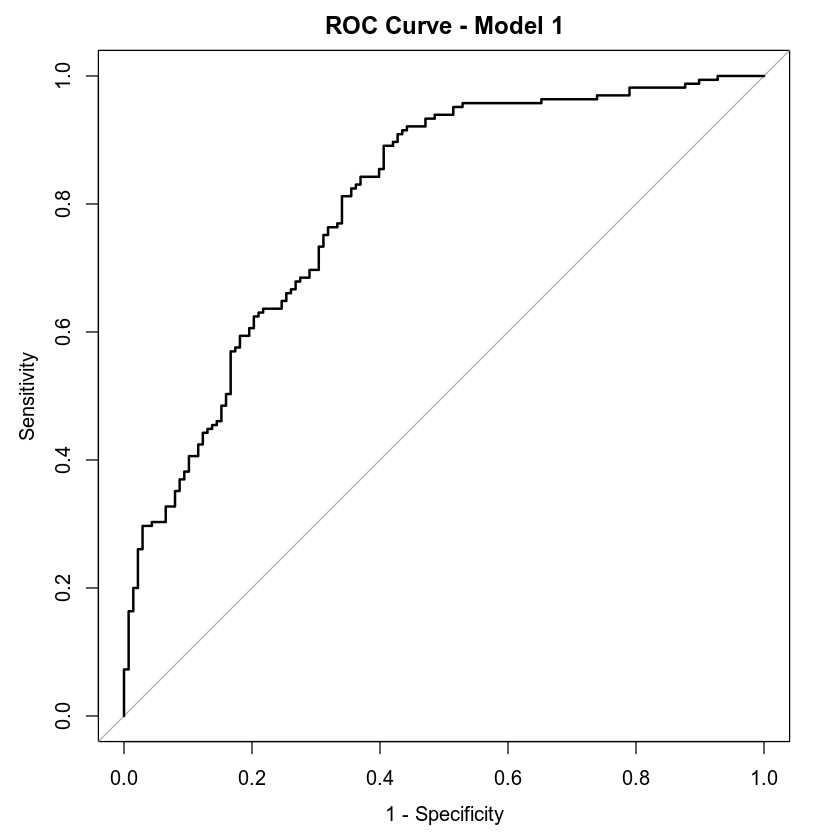

In [9]:
# 4. ROC Curve and AUC Value
library(pROC)
roc1 <- roc(heart_data$target, prob1)
cat(paste("AUC Value:", round(auc(roc1), 4), "\n"))
plot(roc1, legacy.axes = TRUE, xlab = "1 - Specificity", ylab = "Sensitivity", main = "ROC Curve - Model 1")

## Model #2 - Second Logistic Regression Model

You have been asked to create a logistic regression model for heart disease *(target)* using the variables age of the individual *(age)*, resting blood pressure (trestbps), type of chest pain *(cp)* and maximum heart rate achieved *(thalach)*. You also have to include the quadratic term for age and the interaction term between age and maximum heart rate achieved. Before writing any code, review Section 4 of the Summary Report template to see the questions you will be answering about your model.

Run your scripts to get the outputs of your analysis. Then use the outputs to answer the questions in your summary report.

**Note: Use the + (plus) button to add new code blocks, if needed.**

In [10]:
# 1. Fit the second logistic regression model with quadratic and interaction terms
model2 <- glm(target ~ age + I(age^2) + trestbps + exang + thalach + age:thalach, data = heart_data, family = binomial)
summary(model2)


Call:
glm(formula = target ~ age + I(age^2) + trestbps + exang + thalach + 
    age:thalach, family = binomial, data = heart_data)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-2.3489  -0.7818   0.3266   0.8608   2.3295  

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -14.786024  10.251903  -1.442  0.14923    
age           0.160878   0.258640   0.622  0.53393    
I(age^2)      0.001059   0.001696   0.625  0.53228    
trestbps     -0.014332   0.008401  -1.706  0.08801 .  
exang1       -1.562499   0.310116  -5.038 4.69e-07 ***
thalach       0.142205   0.049685   2.862  0.00421 ** 
age:thalach  -0.001963   0.000859  -2.285  0.02231 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 417.64  on 302  degrees of freedom
Residual deviance: 315.13  on 296  degrees of freedom
AIC: 329.13

Number of Fisher Scoring iterations: 5


In [11]:
# 2. Hosmer-Lemeshow Goodness of Fit Test
hl_test2 <- hoslem.test(as.numeric(as.character(heart_data$target)), fitted(model2), g = 10)
print(hl_test2)


	Hosmer and Lemeshow goodness of fit (GOF) test

data:  as.numeric(as.character(heart_data$target)), fitted(model2)
X-squared = 8.36, df = 8, p-value = 0.3991



In [12]:
# 3. Training Confusion Matrix and Evaluation Metrics
prob2 <- predict(model2, type = "response")
pred2 <- ifelse(prob2 > 0.5, 1, 0)
conf_matrix2 <- table(Actual = heart_data$target, Predicted = pred2)
print(conf_matrix2)

      Predicted
Actual   0   1
     0  88  50
     1  30 135


In [13]:
# Calculate Accuracy, Precision, and Recall
accuracy2 <- sum(diag(conf_matrix2)) / sum(conf_matrix2)
precision2 <- conf_matrix2[2, 2] / sum(conf_matrix2[, 2])
recall2 <- conf_matrix2[2, 2] / sum(conf_matrix2[2, ])
cat(paste("\nAccuracy:", round(accuracy2, 4), 
          "\nPrecision:", round(precision2, 4), 
          "\nRecall:", round(recall2, 4), "\n"))


Accuracy: 0.736 
Precision: 0.7297 
Recall: 0.8182 


Setting levels: control = 0, case = 1
Setting direction: controls < cases


AUC Value: 0.8112 


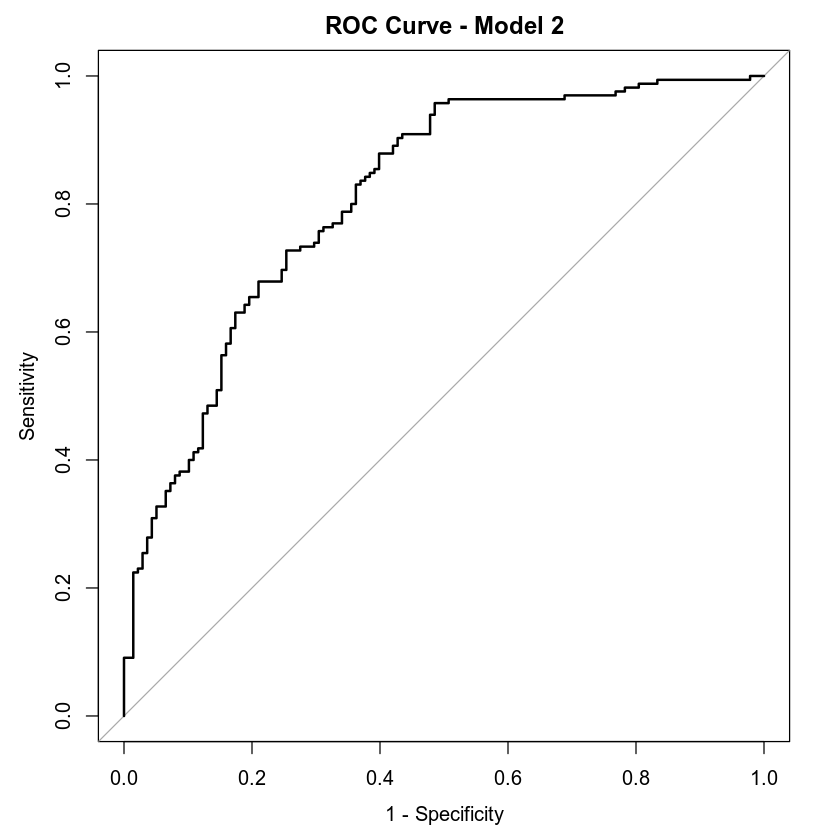

In [13]:
# 4. ROC Curve and AUC Value
roc2 <- roc(heart_data$target, prob2)
cat(paste("AUC Value:", round(auc(roc2), 4), "\n"))
plot(roc2, legacy.axes = TRUE, xlab = "1 - Specificity", ylab = "Sensitivity", main = "ROC Curve - Model 2")

## Random Forest Classification Model

You have been asked to create a random forest classification model for the presence of heart disease *(target)* using the variables age *(age)*, sex *(sex)*, chest pain type *(cp)*, resting blood pressure *(trestbps)*, cholesterol measurement *(chol)*, resting electrocardiographic measurement *(restecg)*, exercise-induced angina *(exang)*, and number of major vessels *(ca)*. Before writing any code, review Section 5 of the Summary Report template to see the questions you will be answering about your model.

Run your scripts to get the outputs of your regression analysis. Then use the outputs to answer the questions in your summary report.

**Note: Use the + (plus) button to add new code blocks, if needed.**

In [14]:
library(randomForest)

# Establish required assignment seed
set.seed(6522048)

# Calculate sample sizes
samp.size <- floor(0.85 * nrow(heart_data))
train_ind <- sample(seq_len(nrow(heart_data)), size = samp.size)

# Create training and testing subsets
train.data <- heart_data[train_ind, ]
test.data  <- heart_data[-train_ind, ]

# Print row counts for your summary report
print("Original dataset rows:")
print(nrow(heart_data))

print("Number of rows for the training set:")
print(nrow(train.data))

print("Number of rows for the testing set:")
print(nrow(test.data))

randomForest 4.6-14
Type rfNews() to see new features/changes/bug fixes.


[1] "Original dataset rows:"
[1] 303
[1] "Number of rows for the training set:"
[1] 257
[1] "Number of rows for the testing set:"
[1] 46


[1] "Optimal number of trees (lowest testing error): 9"


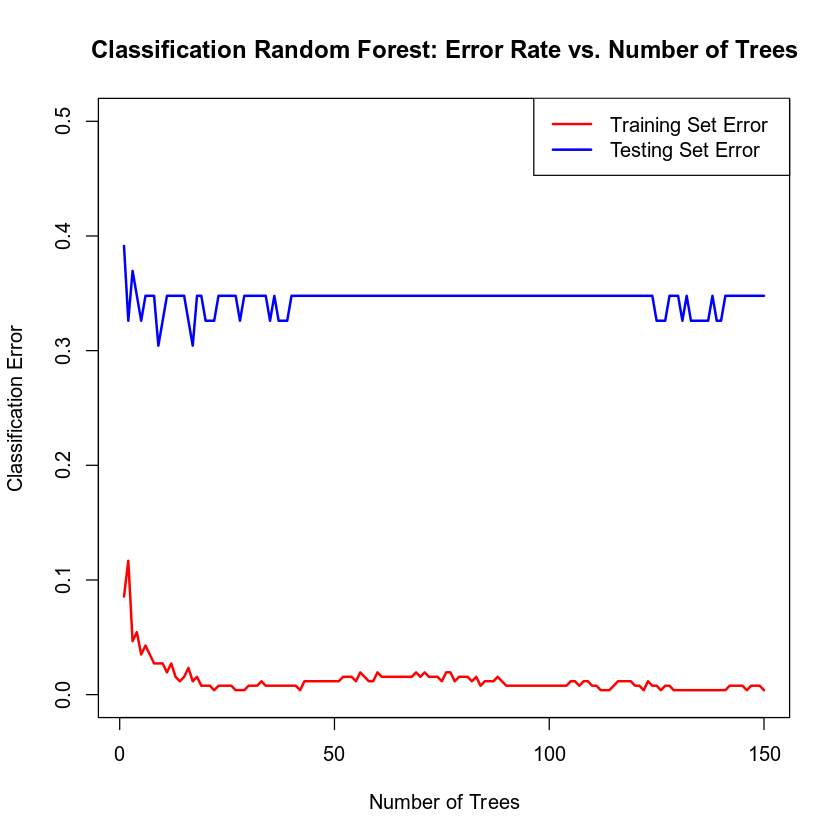

In [15]:
# Initialize empty vectors to capture error track records
train_err_vector <- c()
test_err_vector  <- c()
tree_counts      <- seq(from = 1, to = 150, by = 1)

for(i in tree_counts) {
  # Build a forest with exactly i trees using the exact 8 required variables
  set.seed(6522048)
  model_rf1 <- randomForest(target ~ age + sex + cp + trestbps + chol + restecg + exang + ca, 
                            data = train.data, ntree = i)
  
  # Calculate training set classification error
  pred_train <- predict(model_rf1, train.data, type = "class")
  cm_tr      <- table(train.data$target, pred_train)
  tr_error   <- 1 - (sum(diag(cm_tr)) / sum(cm_tr))
  train_err_vector <- c(train_err_vector, tr_error)
  
  # Calculate testing set classification error
  pred_test  <- predict(model_rf1, test.data, type = "class")
  cm_ts      <- table(test.data$target, pred_test)
  ts_error   <- 1 - (sum(diag(cm_ts)) / sum(cm_ts))
  test_err_vector  <- c(test_err_vector, ts_error)
}

# Find the tree count where testing error reaches its minimum value
optimal_trees <- tree_counts[which.min(test_err_vector)]
print(paste("Optimal number of trees (lowest testing error):", optimal_trees))

# Graph the training and testing error curves
plot(tree_counts, train_err_vector, type = "l", ylim = c(0, 0.5), col = "red", lwd = 2,
     xlab = "Number of Trees", ylab = "Classification Error", 
     main = "Classification Random Forest: Error Rate vs. Number of Trees")
lines(tree_counts, test_err_vector, col = "blue", lwd = 2)
legend("topright", legend = c("Training Set Error", "Testing Set Error"), col = c("red", "blue"), lwd = 2)

In [17]:
# Build optimized forest using the optimal tree count
set.seed(6522048)
model_rf_opt <- randomForest(target ~ age + sex + cp + trestbps + chol + restecg + exang + ca, 
                             data = train.data, ntree = optimal_trees)

# Training predictions
pred_train_final <- predict(model_rf_opt, train.data, type = "class")
cm_train_final   <- table(Actual = train.data$target, Predicted = pred_train_final)

print("=== TRAINING SET CONFUSION MATRIX ===")
print(cm_train_final)

# Compute performance metrics to 4 decimal places
acc_tr <- sum(diag(cm_train_final)) / sum(cm_train_final)
prc_tr <- cm_train_final["1", "1"] / sum(cm_train_final[, "1"])
rcl_tr <- cm_train_final["1", "1"] / sum(cm_train_final["1", ])

print(paste("Training Accuracy: ", round(acc_tr, 4)))
print(paste("Training Precision:", round(prc_tr, 4)))
print(paste("Training Recall:   ", round(rcl_tr, 4)))

[1] "=== TRAINING SET CONFUSION MATRIX ==="
      Predicted
Actual   0   1
     0 117   3
     1   4 133
[1] "Training Accuracy:  0.9728"
[1] "Training Precision: 0.9779"
[1] "Training Recall:    0.9708"


In [18]:
# Testing predictions
pred_test_final <- predict(model_rf_opt, test.data, type = "class")
cm_test_final   <- table(Actual = test.data$target, Predicted = pred_test_final)

print("=== TESTING SET CONFUSION MATRIX ===")
print(cm_test_final)

# FIXED: Replaced := with standard R assignment <- 
acc_ts <- sum(diag(cm_test_final)) / sum(cm_test_final)
prc_ts <- cm_test_final["1", "1"] / sum(cm_test_final[, "1"])
rcl_ts <- cm_test_final["1", "1"] / sum(cm_test_final["1", ])

print(paste("Testing Accuracy: ", round(acc_ts, 4)))
print(paste("Testing Precision:", round(prc_ts, 4)))
print(paste("Testing Recall:   ", round(rcl_ts, 4)))

[1] "=== TESTING SET CONFUSION MATRIX ==="
      Predicted
Actual  0  1
     0 12  6
     1  8 20
[1] "Testing Accuracy:  0.6957"
[1] "Testing Precision: 0.7692"
[1] "Testing Recall:    0.7143"


## Random Forest Regression Model

You have been asked to create a random forest regression model for maximum heart rate achieved using the variables age *(age)*, sex *(sex)*, chest pain type *(cp)*, resting blood pressure *(trestbps)*, cholesterol measurement *(chol)*, resting electrocardiographic measurement *(restecg)*, exercise-induced angina *(exang)*, and number of major vessels *(ca)*. Before writing any code, review Section 6 of the Summary Report template to see the questions you will be answering about your model.

Run your scripts to get the outputs of your analysis. Then use the outputs to answer the questions in your summary report.

**Note: Use the + (plus) button to add new code blocks, if needed.**

In [20]:
library(randomForest)

# Establish required assignment seed for the regression experiment
set.seed(6522048)

# Calculate sample sizes for an 80/20 split
samp.size_reg <- floor(0.80 * nrow(heart_data))
train_ind_reg <- sample(seq_len(nrow(heart_data)), size = samp.size_reg)

# Create regression training and testing subsets
train.data_reg <- heart_data[train_ind_reg, ]
test.data_reg  <- heart_data[-train_ind_reg, ]

# Print row counts for your Section 6 summary report
print("Original dataset rows:")
print(nrow(heart_data))

print("Number of rows for the regression training set:")
print(nrow(train.data_reg))

print("Number of rows for the regression testing set:")
print(nrow(test.data_reg))

[1] "Original dataset rows:"
[1] 303
[1] "Number of rows for the regression training set:"
[1] 242
[1] "Number of rows for the regression testing set:"
[1] 61


[1] "Optimal number of trees (lowest testing MSE): 49"


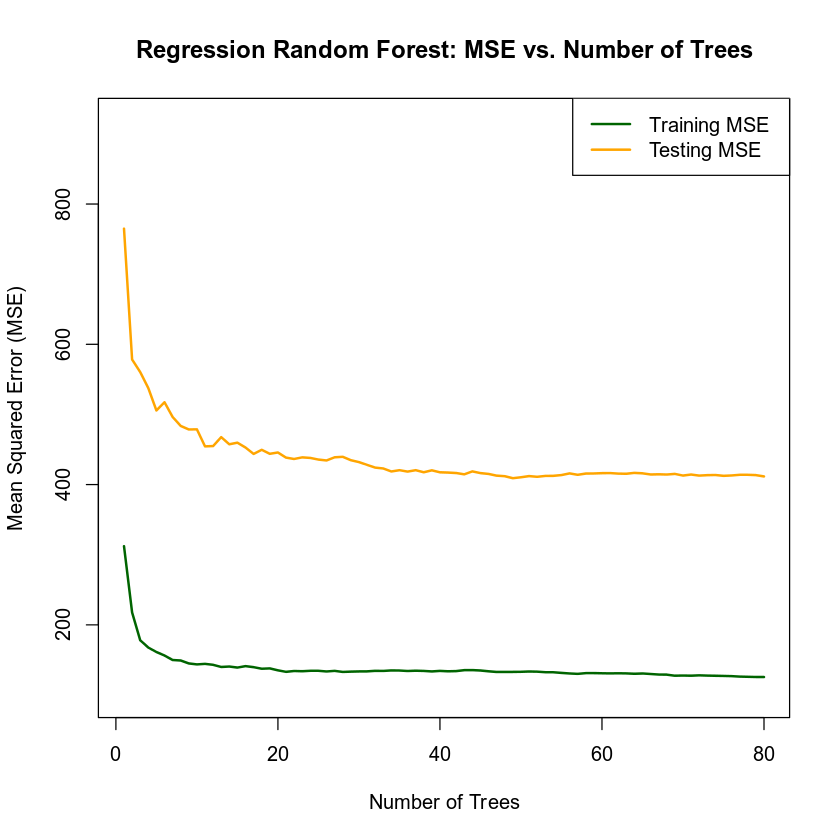

In [22]:
# Initialize empty vectors to capture Mean Squared Error tracking metrics
train_mse_vector <- c()
test_mse_vector  <- c()
tree_counts_reg  <- seq(from = 1, to = 80, by = 1)

for(i in tree_counts_reg) {
  # Build a regression forest with exactly i trees predicting 'thalach'
  set.seed(6522048)
  model_rf2 <- randomForest(thalach ~ age + sex + cp + trestbps + chol + restecg + exang + ca, 
                            data = train.data_reg, ntree = i)
  
  # Calculate training set Mean Squared Error
  pred_train_reg <- predict(model_rf2, train.data_reg)
  tr_mse         <- mean((train.data_reg$thalach - pred_train_reg)^2)
  train_mse_vector <- c(train_mse_vector, tr_mse)
  
  # Calculate testing set Mean Squared Error
  pred_test_reg  <- predict(model_rf2, test.data_reg)
  ts_mse         <- mean((test.data_reg$thalach - pred_test_reg)^2)
  test_mse_vector  <- c(test_mse_vector, ts_mse)
}

# Find the tree count where testing MSE reaches its minimum value
optimal_trees_reg <- tree_counts_reg[which.min(test_mse_vector)]
print(paste("Optimal number of trees (lowest testing MSE):", optimal_trees_reg))

# Graph the training and testing MSE curves against the number of trees
plot(tree_counts_reg, train_mse_vector, type = "l", ylim = c(min(train_mse_vector)*0.8, max(test_mse_vector)*1.2), 
     col = "darkgreen", lwd = 2, xlab = "Number of Trees", ylab = "Mean Squared Error (MSE)", 
     main = "Regression Random Forest: MSE vs. Number of Trees")
lines(tree_counts_reg, test_mse_vector, col = "orange", lwd = 2)
legend("topright", legend = c("Training MSE", "Testing MSE"), col = c("darkgreen", "orange"), lwd = 2)

In [23]:
# Build optimized regression forest using the ideal tree count found in Cell 2
set.seed(6522048)
model_rf2_opt <- randomForest(thalach ~ age + sex + cp + trestbps + chol + restecg + exang + ca, 
                              data = train.data_reg, ntree = optimal_trees_reg)

# Generate final training predictions
final_pred_train_reg <- predict(model_rf2_opt, train.data_reg)

# Calculate Training RMSE (Root Mean Squared Error)
train_rmse <- sqrt(mean((train.data_reg$thalach - final_pred_train_reg)^2))

print("=== TRAINING SET PERFORMANCE ===")
print(paste("Training Set RMSE:", round(train_rmse, 4)))

[1] "=== TRAINING SET PERFORMANCE ==="
[1] "Training Set RMSE: 11.5322"


In [24]:
# Generate final testing predictions
final_pred_test_reg <- predict(model_rf2_opt, test.data_reg)

# Calculate Testing RMSE (Root Mean Squared Error)
test_rmse <- sqrt(mean((test.data_reg$thalach - final_pred_test_reg)^2))

print("=== TESTING SET PERFORMANCE ===")
print(paste("Testing Set RMSE:", round(test_rmse, 4)))

[1] "=== TESTING SET PERFORMANCE ==="
[1] "Testing Set RMSE: 20.2274"


## End of Project Two Jupyter Notebook
The HTML output can be downloaded by clicking **File**, then **Download as**, then **HTML**. Be sure to answer all of the questions in the Summary Report template for Project Two, and to include your completed Jupyter Notebook scripts as part of your submission.